# Data Cleaning Project

## Dataset
Airbnb New York City 2019 Dataset

## Objective
The goal of this project is to clean a real-world dataset by handling:
- Missing values
- Duplicate records
- Inconsistent data
- Outliers

Clean data improves the reliability and quality of analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AB_NYC_2019.csv.zip")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## Handling Missing Values

The dataset contains missing values in:
- name
- host_name
- reviews_per_month

We will:
- Drop rows with missing names
- Fill reviews_per_month with 0

In [8]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [12]:
df = df.dropna(subset=['name','host_name'])

In [13]:
df = df.dropna(subset=['last_review'])

In [14]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## Removing Duplicate Records

Duplicate records can lead to incorrect analysis, so we remove them.

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

## Outlier Detection

Outliers in price may distort analysis. We visualize the distribution to identify extreme values.

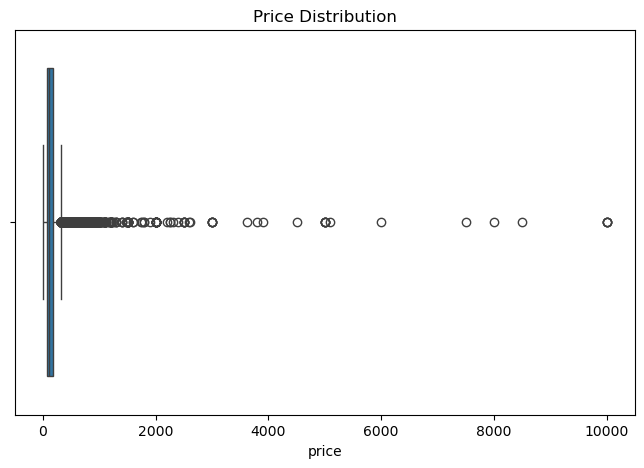

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Price Distribution")
plt.show()

In [18]:
df = df[df['price'] < 500]

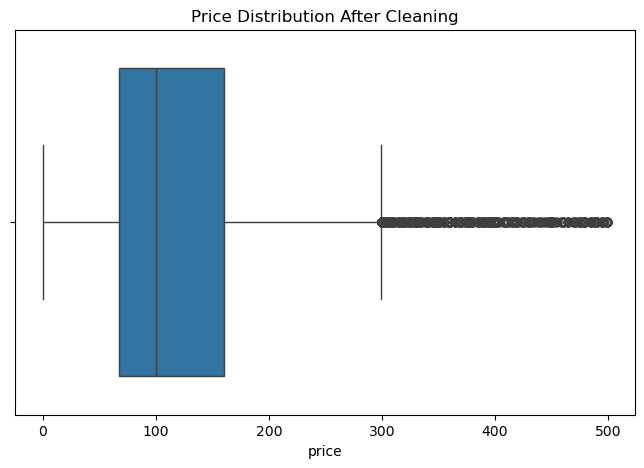

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Price Distribution After Cleaning")
plt.show()

In [20]:
print("Final dataset shape:", df.shape)

Final dataset shape: (38085, 16)


## Cleaned Dataset Summary

In [21]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.808500e+04,3.808500e+04,38085.000000,38085.000000,38085.000000,38085.000000,38085.000000,38085.000000,38085.000000,38085.000000
mean,1.807375e+07,6.389929e+07,40.728025,-73.950691,126.944965,5.862177,29.501378,1.377741,5.127688,113.238099
std,1.067953e+07,7.562243e+07,0.055258,0.046835,81.868308,17.406015,48.407438,1.684826,26.205883,128.937437
min,2.539000e+03,2.438000e+03,40.506410,-74.244420,0.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,8.704348e+06,7.027191e+06,40.688450,-73.982140,67.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,1.884251e+07,2.818745e+07,40.721380,-73.954400,100.000000,2.000000,10.000000,0.720000,1.000000,53.000000
75%,2.752913e+07,1.012765e+08,40.763150,-73.934460,160.000000,4.000000,34.000000,2.030000,2.000000,224.000000
max,3.645581e+07,2.738417e+08,40.913060,-73.712990,499.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [22]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129


In [23]:
df.to_csv("cleaned_airbnb_nyc.csv", index=False)

## Conclusion

In this project we cleaned the Airbnb NYC dataset by:

- Handling missing values
- Removing duplicate records
- Detecting and removing outliers
- Preparing the dataset for further analysis

The cleaned dataset is now ready for data analysis or machine learning tasks.